# 🧠 CT Feature Extraction Visualizations
Visualizing handcrafted features (LBP, GLCM, Fourier, HOG) and t-SNE embedding.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, feature, color, exposure
from scipy.fft import fft2, fftshift
from scipy.stats import entropy
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import glob, os, cv2

In [2]:
# --- Helper to load sample images ---
normal_img = io.imread(sorted(glob.glob('./Pancreas/NPancreas/*.jpg'))[20], as_gray=True)
ap_img = io.imread(sorted(glob.glob('./Pancreas/PPancreas/*.jpg'))[300], as_gray=True)
print(normal_img.shape, ap_img.shape)

(512, 512) (512, 512)


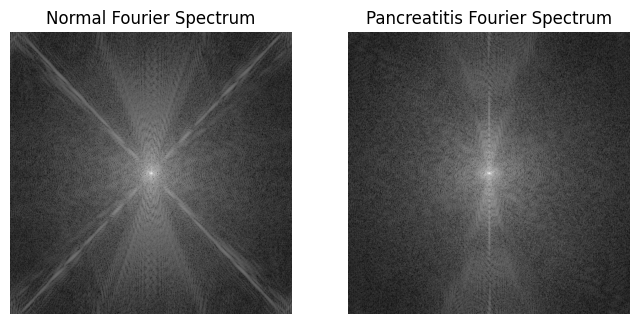

In [3]:
# --- Fourier Spectrum ---
def plot_fourier(img, title):
    f = fftshift(fft2(img))
    mag = np.log(1 + np.abs(f))
    plt.imshow(mag, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plot_fourier(normal_img, 'Normal Fourier Spectrum')
plt.subplot(1,2,2)
plot_fourier(ap_img, 'Pancreatitis Fourier Spectrum')
plt.show()

C:\Users\Tahir\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


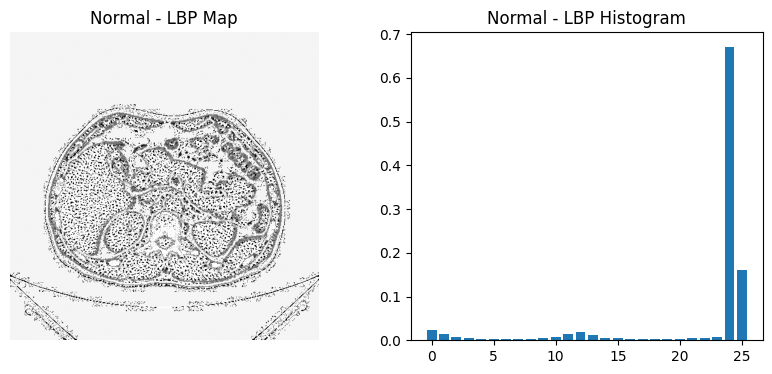

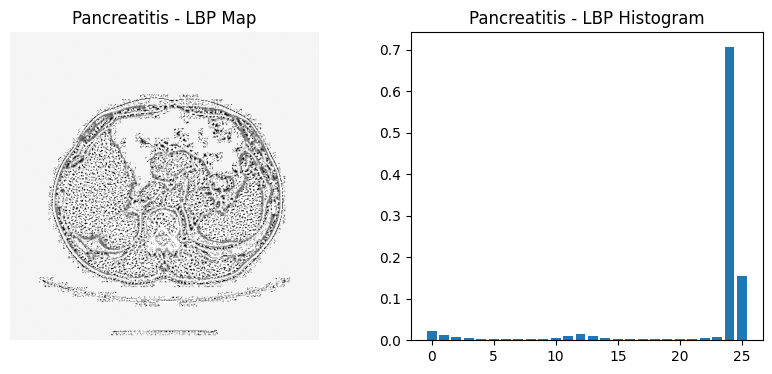

In [4]:
# --- LBP ---
def plot_lbp(img, title):
    lbp = feature.local_binary_pattern(img, P=24, R=3, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=int(lbp.max()+1), range=(0, lbp.max()+1), density=True)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(lbp, cmap='gray')
    plt.title(f'{title} - LBP Map')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.bar(np.arange(len(hist)), hist)
    plt.title(f'{title} - LBP Histogram')
    plt.show()

plot_lbp(normal_img, 'Normal')
plot_lbp(ap_img, 'Pancreatitis')

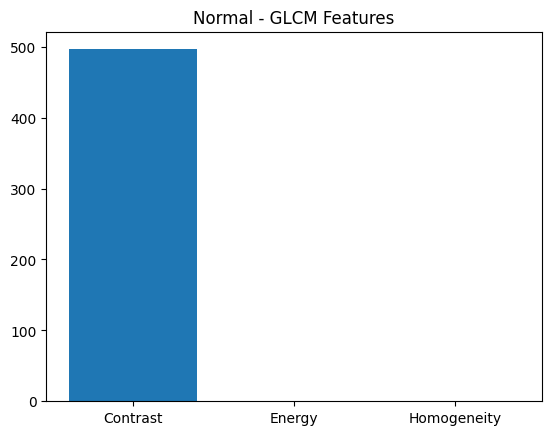

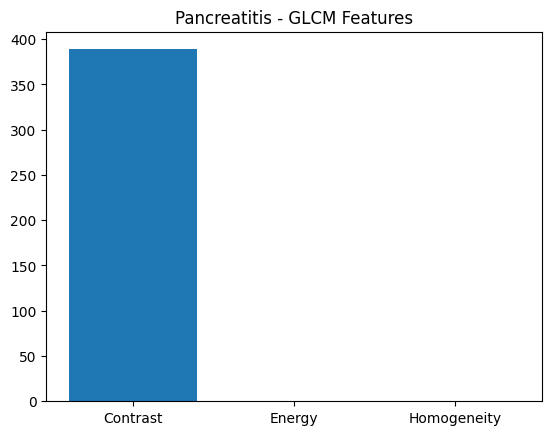

In [5]:
# --- GLCM ---
def plot_glcm(img, title):
    img8 = (img * 255).astype(np.uint8)
    glcm = feature.graycomatrix(img8, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256, symmetric=True, normed=True)
    contrast = feature.graycoprops(glcm, 'contrast').mean()
    energy = feature.graycoprops(glcm, 'energy').mean()
    homo = feature.graycoprops(glcm, 'homogeneity').mean()
    plt.figure()
    plt.bar(['Contrast','Energy','Homogeneity'], [contrast, energy, homo])
    plt.title(f'{title} - GLCM Features')
    plt.show()

plot_glcm(normal_img, 'Normal')
plot_glcm(ap_img, 'Pancreatitis')

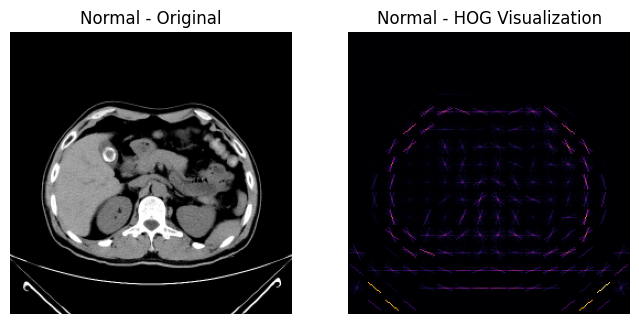

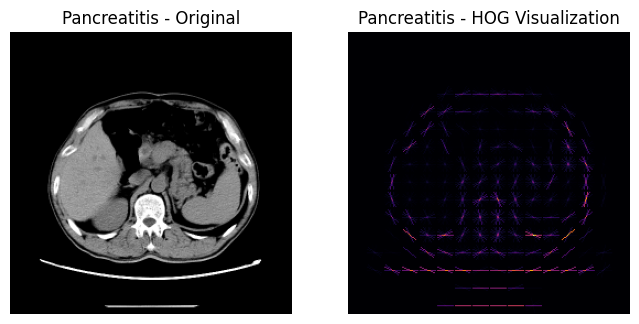

In [6]:
# --- HOG Visualization ---
def plot_hog(img, title):
    img_resized = cv2.resize(img, (256,256))
    features, hog_image = feature.hog(img_resized, orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2), visualize=True, block_norm='L2-Hys')
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img_resized, cmap='gray')
    plt.title(f'{title} - Original')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(hog_image, cmap='inferno')
    plt.title(f'{title} - HOG Visualization')
    plt.axis('off')
    plt.show()

plot_hog(normal_img, 'Normal')
plot_hog(ap_img, 'Pancreatitis')

In [7]:
# --- t-SNE using CT features ---
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Assuming X_scaled and y are already available from your feature extraction code
print("Running t-SNE on CT feature matrix:", X_scaled.shape)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
scatter = plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y, cmap='coolwarm', s=10, alpha=0.7)
plt.colorbar(scatter, label="0 = Normal, 1 = Acute Pancreatitis")
plt.title("t-SNE Projection of Handcrafted CT Features")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


NameError: name 'X_scaled' is not defined